In [1]:
import numpy as np
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import spearmanr
import pandas as pd

50 条真实 Cas12a 错配数据集

In [2]:
data = [
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "AGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.244067,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "GGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.536652,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "TGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.349063,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CAGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.002632,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CCGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.327277,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CTGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.293087,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGATTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.108303,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGCTTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.294277,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGTTTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.230956,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGATCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.275075,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGCTCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.259007,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGGTCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.422551,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTACGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.206470,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTCCGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.287469,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTGCGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.460275,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTAGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.150048,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTGGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.344187,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTTGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.151763,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCACGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 0.966740,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCCCGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 1.109856,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCTCGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 1.107226,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGAGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.085175,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGGGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.202152,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGTGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.058207,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCATGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.037646,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCCTGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.133941,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCTTGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.131164,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGAGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.108452,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGCGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.241383,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGGGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.171693,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTAGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.054520,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTCGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.267676,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTTGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.222937,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGAATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 0.994914,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGCATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 1.275432,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGTATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 1.181162,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGCTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.315327,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGGTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.241909,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGTTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.321736,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGAATAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.173173,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGACTAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.114124,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGAGTAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.276508,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATAAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.171015,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATCAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.209477,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATGAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.376292,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTCAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.349096,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTGAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.274115,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTTAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.199478,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTACAGG",
        "mismatch_pos": 16,
        "relative_activity": 1.355353,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTAGAGG",
        "mismatch_pos": 16,
        "relative_activity": 1.332736,
    },
]

df = pd.DataFrame(data)

## 特征工程 v4（修正版）

v4 相比 v3 的两处关键修正：
1. 计算 ddG 时对 target 取 reverse-complement，符合 RNA-DNA 双链实际配对方向
2. 序列先统一归一化为 RNA（T→U），确保碱基比较一致

v3 直接将 target 原链传入 `duplexfold`，且保留 DNA 字母，导致能量计算偏差。

In [3]:
from __future__ import annotations
from typing import Optional
import numpy as np


def normalize_rna(sequence: str) -> str:
    value = str(sequence).upper().replace('T', 'U').replace(' ', '')
    if not value or any(base not in 'ACGU' for base in value):
        raise ValueError(f'Invalid RNA/DNA sequence: {sequence!r}')
    return value


def reverse_complement_rna(sequence: str) -> str:
    sequence = normalize_rna(sequence)
    complement = {'A': 'U', 'U': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement[base] for base in reversed(sequence))


def find_mismatch_positions(spacer: str, target: str) -> list:
    spacer_rna = normalize_rna(spacer)
    target_rna = normalize_rna(target)
    if len(spacer_rna) != len(target_rna):
        raise ValueError(f'Length mismatch: {len(spacer_rna)} != {len(target_rna)}')
    return [i for i, (s, t) in enumerate(zip(spacer_rna, target_rna)) if s != t]


def _duplex_energy(spacer_rna: str, target_rna_same_orientation: str) -> float:
    # target 取 reverse-complement 后再 duplexfold，对应实际 RNA-DNA 配对
    import RNA
    pairing_strand = reverse_complement_rna(target_rna_same_orientation)
    return float(RNA.duplexfold(spacer_rna, pairing_strand).energy)


def extract_final_features_v4(
    spacer: str,
    target: str,
    mismatch_pos=None,
) -> list:
    spacer_rna = normalize_rna(spacer)
    target_rna = normalize_rna(target)
    if len(spacer_rna) != 20 or len(target_rna) != 20:
        raise ValueError('Cas12a spacer and protospacer must both be 20 nt')

    inferred = find_mismatch_positions(spacer_rna, target_rna)
    if mismatch_pos is not None and mismatch_pos >= 0:
        if mismatch_pos >= 20:
            raise ValueError(f'mismatch_pos out of range: {mismatch_pos}')
        if mismatch_pos not in inferred:
            raise ValueError(
                f'mismatch_pos={mismatch_pos} is not a mismatch in the supplied sequences'
            )
        mismatch_positions = [mismatch_pos]
    else:
        # mismatch_pos < 0 or None：从序列对比自动推断
        mismatch_positions = inferred

    dg_duplex = _duplex_energy(spacer_rna, target_rna)
    dg_perfect = _duplex_energy(spacer_rna, spacer_rna)
    ddg = dg_duplex - dg_perfect if mismatch_positions else 0.0

    if not mismatch_positions:
        pos = -1.0
        is_purine_mismatch = 0.0
        is_transition = 0.0
        is_edge = 0.0
        mismatch_score = 0.0
        seed_weight = 1.0
    else:
        pos = float(min(mismatch_positions))
        spacer_base = spacer_rna[int(pos)]
        target_base = target_rna[int(pos)]
        is_purine_mismatch = float(spacer_base in 'AG' and target_base in 'AG')
        is_transition = float(
            (spacer_base, target_base) in {('A','G'),('G','A'),('C','U'),('U','C')}
        )
        is_edge = float(pos <= 2 or pos >= 17)
        mismatch_score = {
            ('A','C'): 3.0, ('C','A'): 3.0,
            ('G','A'): 2.0, ('A','G'): 2.0,
            ('C','U'): 1.0, ('U','C'): 1.0,
            ('G','U'): 0.0, ('U','G'): 0.0,
        }.get((spacer_base, target_base), 2.0)
        seed_weight = 1.5 if pos <= 8 else 1.0

    pos_ddg_interaction = pos * ddg if pos >= 0 else 0.0
    return [pos, ddg, is_purine_mismatch, is_transition,
            is_edge, pos_ddg_interaction, mismatch_score, seed_weight]


# 兼容别名
extract_final_features = extract_final_features_v4

FEATURE_NAMES = [
    'mismatch_pos', 'ddg', 'is_purine_mismatch', 'is_transition',
    'is_edge', 'pos_ddg_interaction', 'mismatch_score', 'seed_weight',
]

print('extract_final_features_v4 已定义（inline，不依赖外部文件）')


extract_final_features_v4 已定义（inline，不依赖外部文件）


In [4]:
import numpy as np
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import spearmanr
import pandas as pd

# ===== 用 v4 特征重新提取 =====
X_final = np.array([
    extract_final_features_v4(row['spacer_seq'], row['target_seq'], row['mismatch_pos'])
    for _, row in df.iterrows()
])
y = df['relative_activity'].values

# ===== 模型定义 =====
svr = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=20, epsilon=0.05, gamma=0.05))
gb  = GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                learning_rate=0.05, subsample=0.8, random_state=42)

# ===== LOO 交叉验证预测 =====
y_pred_svr = cross_val_predict(svr, X_final, y, cv=LeaveOneOut())
y_pred_gb  = cross_val_predict(gb,  X_final, y, cv=LeaveOneOut())
y_pred = (y_pred_svr + y_pred_gb) / 2

rho, p = spearmanr(y, y_pred)
print(f'v4 (8特征 + 修正ddG方向): r_s = {rho:.3f}, p = {p:.4e}')
print(f'X_final shape: {X_final.shape}')
print(f'X_final[:3]:\n{X_final[:3]}')


v4 (8特征 + 修正ddG方向): r_s = 0.692, p = 2.6593e-08
X_final shape: (50, 8)
X_final[:3]:
[[0.  1.  0.  0.  1.  0.  3.  1.5]
 [0.  1.3 0.  0.  1.  0.  2.  1.5]
 [0.  0.9 0.  1.  1.  0.  1.  1.5]]


In [5]:
# ===== v3（保留对比，不建议用于新实验）=====
# 已知问题：target 未取 reverse-complement；DNA/RNA 字母混用
def extract_final_features_v3(spacer, target, mismatch_pos):
    import RNA
    duplex = RNA.duplexfold(spacer, target)
    dg_duplex = duplex.energy
    dg_perfect = RNA.duplexfold(spacer, spacer.replace('U', 'T')).energy
    ddg = dg_duplex - dg_perfect
    pos = int(mismatch_pos)
    sp_base = spacer[pos] if pos < len(spacer) else 'N'
    tg_base = target[pos] if pos < len(target) else 'N'
    is_purine_mismatch = 1 if (sp_base in ['A','G'] and tg_base in ['A','G']) else 0
    transitions = [('A','G'),('G','A'),('C','T'),('T','C')]
    is_transition = 1 if (sp_base, tg_base) in transitions else 0
    is_edge = 1 if (pos <= 2 or pos >= 17) else 0
    pos_ddg_interaction = pos * ddg
    mismatch_severity = {
        ('A','C'):3,('C','A'):3,('G','A'):2,('A','G'):2,
        ('C','T'):1,('T','C'):1,('G','T'):0,('T','G'):0,
        ('U','G'):0,('G','U'):0,
    }
    mismatch_score = mismatch_severity.get((sp_base, tg_base), 2)
    seed_weight = 1.5 if pos <= 8 else 1.0
    return [pos, ddg, is_purine_mismatch, is_transition,
            is_edge, pos_ddg_interaction, mismatch_score, seed_weight]

X_v3 = np.array([
    extract_final_features_v3(row['spacer_seq'], row['target_seq'], row['mismatch_pos'])
    for _, row in df.iterrows()
])
svr_v3 = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=20, epsilon=0.05, gamma=0.05))
gb_v3  = GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                    learning_rate=0.05, subsample=0.8, random_state=42)
y_pred_svr_v3 = cross_val_predict(svr_v3, X_v3, y, cv=LeaveOneOut())
y_pred_gb_v3  = cross_val_predict(gb_v3,  X_v3, y, cv=LeaveOneOut())
y_pred_v3 = (y_pred_svr_v3 + y_pred_gb_v3) / 2
rho_v3, p_v3 = spearmanr(y, y_pred_v3)
print(f'v3 (对比参考): r_s = {rho_v3:.3f}, p = {p_v3:.4e}')


v3 (对比参考): r_s = 0.721, p = 3.6449e-09


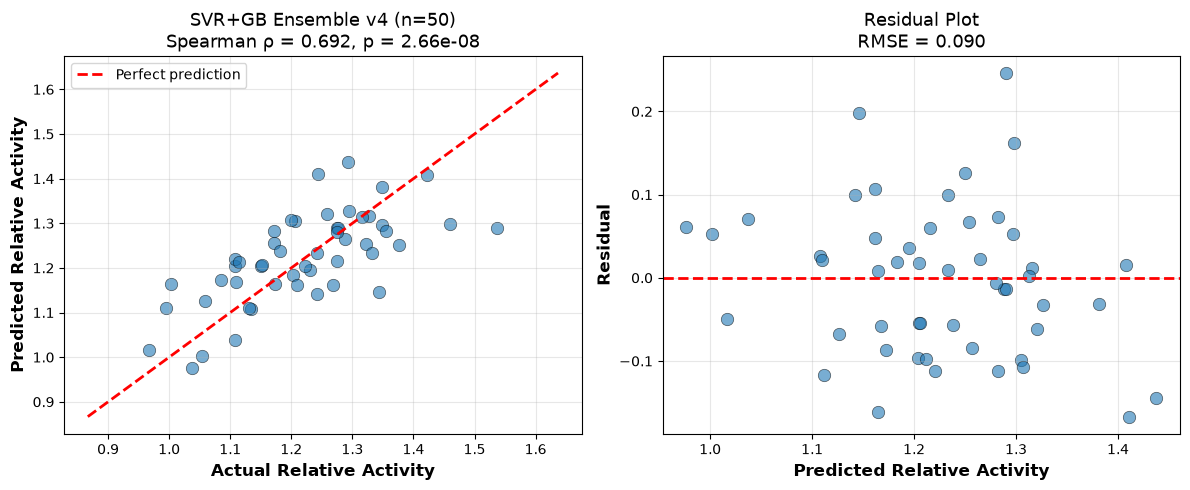

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(y, y_pred, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
lim = [min(y.min(), y_pred.min()) - 0.1, max(y.max(), y_pred.max()) + 0.1]
ax1.plot(lim, lim, 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Relative Activity', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Relative Activity', fontsize=12, fontweight='bold')
ax1.set_title(f'SVR+GB Ensemble v4 (n=50)\nSpearman ρ = {rho:.3f}, p = {p:.2e}', fontsize=13)
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
residuals = y - y_pred
ax2.scatter(y_pred, residuals, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Relative Activity', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residual', fontsize=12, fontweight='bold')
ax2.set_title(f'Residual Plot\nRMSE = {rmse:.3f}', fontsize=13)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_v4_performance.png', dpi=300, bbox_inches='tight')
plt.show()


In [7]:
import numpy as np
import pandas as pd

MIR29A = 'UAGCACCAUCUGAAAUCGGUUA'
MIR29B = 'UAGCACCAUUUGAAAUCAGUGUU'
MIR29C = 'UAGCACCAUUUGAAAUCGGUUA'

def find_mismatches(spacer: str, target: str) -> list:
    s = spacer.upper().replace('T', 'U')
    t = target.upper().replace('T', 'U')
    if len(s) != 20 or len(t) != 20:
        raise ValueError(f'Expected 20-nt sequences, got {len(s)} and {len(t)}')
    return [i for i, (sb, tb) in enumerate(zip(s, t)) if sb != tb]

def target_window(target_seq: str, window_start_nt: int) -> str:
    start = max(0, min(int(window_start_nt) - 1, len(target_seq) - 20))
    return target_seq[start:start + 20]

candidates = pd.read_csv('candidate_sequences_corrected.csv')
candidates.rename(columns={
    'crRNA_spacer_rna_5to3': 'spacer_seq',
    'target_protospacer_dna_5to3': 'target_seq'
}, inplace=True)

targets = {
    'mir29a': MIR29A,
    'mir29b': MIR29B,
    'mir29c': MIR29C,
}

svr.fit(X_final, y)
gb.fit(X_final, y)

pred_dict = {}
for mirna_name, full_target_seq in targets.items():
    features = []
    for _, row in candidates.iterrows():
        spacer = row['spacer_seq']
        target_seq = target_window(full_target_seq, row['window_start_nt'])
        mm_list = find_mismatches(spacer, target_seq)
        mm_pos = mm_list[0] if mm_list else -1
        features.append(extract_final_features_v4(spacer, target_seq, mm_pos))
    X = np.array(features)
    pred_dict[mirna_name] = (svr.predict(X) + gb.predict(X)) / 2

candidates['activity_29a'] = pred_dict['mir29a']
candidates['activity_29b'] = pred_dict['mir29b']
candidates['activity_29c'] = pred_dict['mir29c']

eps = 1e-6
candidates['selectivity_ratio'] = candidates['activity_29a'] / (
    candidates[['activity_29b', 'activity_29c']].max(axis=1) + eps
)
result = candidates.sort_values('selectivity_ratio', ascending=False)
result.to_csv('ranked_crRNA_selectivity_v4.csv', index=False)
print(f'Total candidates: {len(result)}')
print(f'Candidates with selectivity_ratio >= 10: {(result["selectivity_ratio"] >= 10).sum()}')
print(result[['candidate_id', 'spacer_seq', 'activity_29a', 'activity_29b', 'activity_29c', 'selectivity_ratio']].head(10))

Total candidates: 10
Candidates with selectivity_ratio >= 10: 0
     candidate_id            spacer_seq  activity_29a  activity_29b  \
1  CRRNA-CORR-002  AGCACCAUCUGAAAUCGGUU      1.536494      1.209832   
2  CRRNA-CORR-003  GCACCAUCUGAAAUCGGUUA      1.536494      1.240831   
0  CRRNA-CORR-001  UAGCACCAUCUGAAAUCGGU      1.536494      1.279525   
6  CRRNA-CORR-007  CACCAUUUGAAAUCAGUGUU      1.460615      1.536494   
9  CRRNA-CORR-010  GCACCAUUUGAAAUCGGUUA      1.210300      1.274810   
8  CRRNA-CORR-009  AGCACCAUUUGAAAUCGGUU      1.203747      1.142079   
7  CRRNA-CORR-008  UAGCACCAUUUGAAAUCGGU      1.191407      1.170097   
5  CRRNA-CORR-006  GCACCAUUUGAAAUCAGUGU      1.176786      1.536494   
3  CRRNA-CORR-004  UAGCACCAUUUGAAAUCAGU      1.150647      1.536494   
4  CRRNA-CORR-005  AGCACCAUUUGAAAUCAGUG      1.140995      1.536494   

   activity_29c  selectivity_ratio  
1      1.146571           1.270004  
2      1.133339           1.238277  
0      1.228186           1.200831  
6     

In [8]:
import numpy as np
import pandas as pd

candidates2 = pd.read_csv('candidate_sequences_corrected.csv')
candidates2.rename(columns={
    'crRNA_spacer_rna_5to3': 'spacer_seq',
    'target_protospacer_dna_5to3': 'target_seq'
}, inplace=True)

X_candidates = np.array([
    extract_final_features_v4(row['spacer_seq'], row['target_seq'], -1)
    for _, row in candidates2.iterrows()
])

pred_activity = (svr.predict(X_candidates) + gb.predict(X_candidates)) / 2
candidates2['predicted_activity'] = pred_activity
candidates2.sort_values('predicted_activity', ascending=False).to_csv(
    'ranked_crRNA_v4.csv', index=False
)
print(candidates2[['candidate_id', 'spacer_seq', 'predicted_activity']].to_string())

     candidate_id            spacer_seq  predicted_activity
0  CRRNA-CORR-001  UAGCACCAUCUGAAAUCGGU            1.536494
1  CRRNA-CORR-002  AGCACCAUCUGAAAUCGGUU            1.536494
2  CRRNA-CORR-003  GCACCAUCUGAAAUCGGUUA            1.536494
3  CRRNA-CORR-004  UAGCACCAUUUGAAAUCAGU            1.536494
4  CRRNA-CORR-005  AGCACCAUUUGAAAUCAGUG            1.536494
5  CRRNA-CORR-006  GCACCAUUUGAAAUCAGUGU            1.536494
6  CRRNA-CORR-007  CACCAUUUGAAAUCAGUGUU            1.536494
7  CRRNA-CORR-008  UAGCACCAUUUGAAAUCGGU            1.536494
8  CRRNA-CORR-009  AGCACCAUUUGAAAUCGGUU            1.536494
9  CRRNA-CORR-010  GCACCAUUUGAAAUCGGUUA            1.536494


## 模型审计 / Model Audit

本节对当前 v4 的 LbCas12a 模型进行可复核审计：记录 RMSE、MAE、R²、Pearson 和 Spearman 指标，检查残差、特征矩阵、序列长度和数据覆盖范围，并按 mismatch_pos 汇总误差。

**解释边界 / Interpretation boundary:** 当前训练数据为 50 条 LbCas12a 错配样本，主要由同一 spacer 的错配位置变化构成。因而本单元的逐行 LOO 结果主要反映错配位置行为，不能证明模型对未见过的 crRNA spacer 序列具有泛化能力。进行新 crRNA 实验前，仍需用不同 spacer 的独立数据进行按 spacer 分组的外部验证。

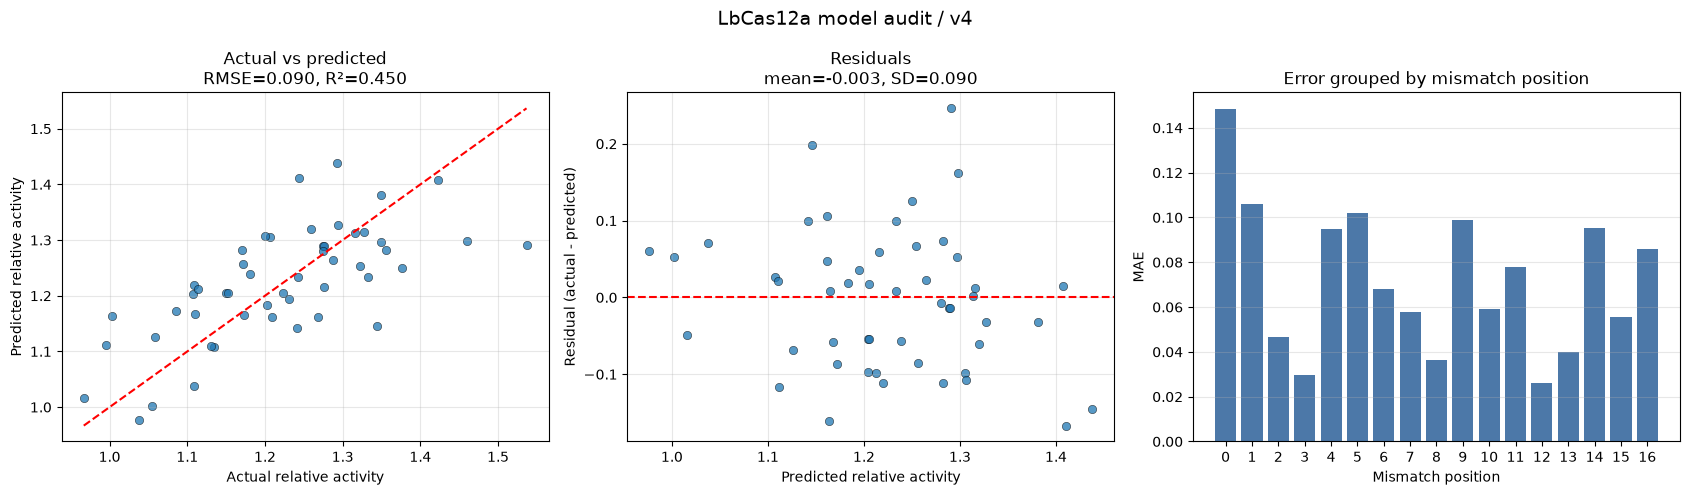

model                                                    SVR+GB ensemble v4
cas_variant                                                        LbCas12a
n_samples                                                                50
n_features                                                                8
feature_matrix_shape                                                (50, 8)
all_features_finite                                                    True
all_predictions_finite                                                 True
spacer_length_all_20nt                                                 True
target_length_all_20nt                                                 True
mismatch_pos_min                                                          0
mismatch_pos_max                                                         16
mismatch_pos_unique                0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
unique_spacers                                                            1
activity_min

In [9]:
# ===== v4 模型审计 / Model audit =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr


def _safe_correlation(correlation_fn, actual, predicted):
    """Return NaN instead of raising when a vector is constant or too short."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    if len(actual) < 2 or np.ptp(actual) == 0 or np.ptp(predicted) == 0:
        return np.nan, np.nan
    statistic, p_value = correlation_fn(actual, predicted)
    return float(statistic), float(p_value)


actual = np.asarray(y, dtype=float)
predicted = np.asarray(y_pred, dtype=float)
features = np.asarray(X_final, dtype=float)
residuals = actual - predicted

if len(actual) != len(predicted) or len(actual) != len(df):
    raise ValueError('Audit vectors and df must have the same number of rows')
if not np.isfinite(actual).all() or not np.isfinite(predicted).all():
    raise ValueError('Actual activity and predictions must contain only finite values')
if features.ndim != 2 or not np.isfinite(features).all():
    raise ValueError(f'Feature matrix must be a finite 2-D array; got {features.shape}')

rmse = float(np.sqrt(mean_squared_error(actual, predicted)))
mae = float(mean_absolute_error(actual, predicted))
r2 = float(r2_score(actual, predicted))
pearson_r, pearson_p = _safe_correlation(pearsonr, actual, predicted)
spearman_r, spearman_p = _safe_correlation(spearmanr, actual, predicted)

spacer_lengths = df['spacer_seq'].astype(str).str.replace('T', 'U', regex=False).str.len()
target_lengths = df['target_seq'].astype(str).str.replace('T', 'U', regex=False).str.len()
mismatch_positions = pd.to_numeric(df['mismatch_pos'], errors='coerce')

audit_summary = {
    'model': 'SVR+GB ensemble v4',
    'cas_variant': 'LbCas12a',
    'n_samples': int(len(actual)),
    'n_features': int(features.shape[1]),
    'feature_matrix_shape': str(tuple(features.shape)),
    'all_features_finite': bool(np.isfinite(features).all()),
    'all_predictions_finite': bool(np.isfinite(predicted).all()),
    'spacer_length_all_20nt': bool((spacer_lengths == 20).all()),
    'target_length_all_20nt': bool((target_lengths == 20).all()),
    'mismatch_pos_min': int(mismatch_positions.min()),
    'mismatch_pos_max': int(mismatch_positions.max()),
    'mismatch_pos_unique': ','.join(map(str, sorted(mismatch_positions.dropna().astype(int).unique()))),
    'unique_spacers': int(df['spacer_seq'].nunique()),
    'activity_min': float(df['relative_activity'].min()),
    'activity_max': float(df['relative_activity'].max()),
    'activity_mean': float(df['relative_activity'].mean()),
    'residual_mean': float(residuals.mean()),
    'residual_std': float(residuals.std(ddof=1)),
    'residual_min': float(residuals.min()),
    'residual_max': float(residuals.max()),
    'rmse': rmse,
    'mae': mae,
    'r2': r2,
    'pearson_r': pearson_r,
    'pearson_p': pearson_p,
    'spearman_r': spearman_r,
    'spearman_p': spearman_p,
    'generalization_note': (
        'Row-wise LOO mainly audits mismatch-position behavior because the dataset uses '
        'one repeated spacer; it does not establish generalization to unseen crRNA spacers.'
    ),
}

audit_rows = pd.DataFrame({
    'mismatch_pos': mismatch_positions.astype(int),
    'actual': actual,
    'predicted': predicted,
    'residual': residuals,
    'absolute_error': np.abs(residuals),
})
error_by_pos = (
    audit_rows.groupby('mismatch_pos', as_index=False)
    .agg(
        n=('absolute_error', 'size'),
        mae=('absolute_error', 'mean'),
        rmse=('residual', lambda values: float(np.sqrt(np.mean(np.square(values))))),
        mean_actual=('actual', 'mean'),
        mean_predicted=('predicted', 'mean'),
        mean_residual=('residual', 'mean'),
    )
)

pd.DataFrame([audit_summary]).to_csv('model_v4_audit_metrics.csv', index=False)
error_by_pos.to_csv('model_v4_error_by_mismatch_position.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].scatter(actual, predicted, alpha=0.75, edgecolors='black', linewidth=0.4)
plot_min = min(actual.min(), predicted.min())
plot_max = max(actual.max(), predicted.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual relative activity')
axes[0].set_ylabel('Predicted relative activity')
axes[0].set_title(f'Actual vs predicted\nRMSE={rmse:.3f}, R²={r2:.3f}')
axes[0].grid(alpha=0.3)

axes[1].scatter(predicted, residuals, alpha=0.75, edgecolors='black', linewidth=0.4)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted relative activity')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title(f'Residuals\nmean={residuals.mean():.3f}, SD={residuals.std(ddof=1):.3f}')
axes[1].grid(alpha=0.3)

axes[2].bar(error_by_pos['mismatch_pos'].astype(str), error_by_pos['mae'], color='#4C78A8')
axes[2].set_xlabel('Mismatch position')
axes[2].set_ylabel('MAE')
axes[2].set_title('Error grouped by mismatch position')
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('LbCas12a model audit / v4', fontsize=14)
fig.tight_layout()
fig.savefig('model_v4_audit.png', dpi=300, bbox_inches='tight')
plt.show()

print(pd.Series(audit_summary).to_string())
print('\nError by mismatch position:')
print(error_by_pos.to_string(index=False))
print('\nSaved: model_v4_audit_metrics.csv, model_v4_error_by_mismatch_position.csv, model_v4_audit.png')

## 可复现环境检查 / Reproducible Environment Check

运行下面的代码单元格，记录 Python、操作系统、关键依赖包、ViennaRNA 和 Jupyter 内核信息。代码不会安装或升级任何包，只读取当前 notebook 内核环境，并生成 JSON、CSV、Markdown 和 pip freeze 记录。

In [10]:
# ===== 可复现环境检查：只读取，不安装/升级任何包 =====
import csv
import datetime as dt
import importlib
import importlib.metadata as metadata
import json
import os
import platform
import subprocess
import sys
from pathlib import Path


def package_version(package_name):
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return 'NOT INSTALLED'
    except Exception as exc:
        return f'ERROR: {type(exc).__name__}: {exc}'


def import_status(module_name):
    try:
        module = importlib.import_module(module_name)
        return {'status': 'ok', 'file': getattr(module, '__file__', None)}
    except Exception as exc:
        return {'status': f'{type(exc).__name__}: {exc}', 'file': None}


package_names = [
    'numpy', 'pandas', 'scipy', 'scikit-learn', 'matplotlib',
    'ViennaRNA', 'jupyter', 'notebook', 'nbformat', 'nbclient',
]
module_names = ['numpy', 'pandas', 'scipy', 'sklearn', 'matplotlib', 'RNA']

manifest = {
    'record_type': 'mirna-crispr-ml reproducibility manifest',
    'recorded_at_local': dt.datetime.now().astimezone().isoformat(),
    'python_version': sys.version,
    'python_executable': sys.executable,
    'platform': platform.platform(),
    'system': platform.system(),
    'machine': platform.machine(),
    'processor': platform.processor(),
    'notebook_file': os.path.abspath('最终模型（SVR+GB 8特征+新参数）_v4_audited.ipynb'),
    'working_directory': os.getcwd(),
    'packages': {name: package_version(name) for name in package_names},
    'module_import_status': {name: import_status(name) for name in module_names},
    'model': {
        'cas_variant': 'LbCas12a',
        'feature_function': 'extract_final_features_v4',
        'feature_count_expected': 8,
        'svr': {'kernel': 'rbf', 'C': 20, 'epsilon': 0.05, 'gamma': 0.05},
        'gradient_boosting': {
            'n_estimators': 100,
            'max_depth': 2,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'random_state': 42,
        },
        'cross_validation': 'LeaveOneOut',
        'ensemble': 'mean(SVR, GradientBoostingRegressor)',
    },
    'reproducibility_notes': [
        'The training data are 50 LbCas12a mismatch samples embedded in the notebook.',
        'The dataset mainly varies mismatch position for one repeated spacer.',
        'Row-wise LOO does not establish generalization to unseen crRNA spacers.',
        'Record the notebook cell outputs and the exact input data file together with this manifest.',
    ],
}

output_dir = Path('environment_records')
output_dir.mkdir(exist_ok=True)

with open(output_dir / 'model_v4_environment_manifest.json', 'w', encoding='utf-8') as handle:
    json.dump(manifest, handle, ensure_ascii=False, indent=2)

flat_rows = [
    {'category': 'runtime', 'name': key, 'version_or_value': value}
    for key, value in manifest.items()
    if not isinstance(value, (dict, list))
]
flat_rows.extend(
    {'category': 'package', 'name': name, 'version_or_value': version}
    for name, version in manifest['packages'].items()
)
flat_rows.extend(
    {'category': 'module_import', 'name': name, 'version_or_value': details['status']}
    for name, details in manifest['module_import_status'].items()
)
with open(output_dir / 'model_v4_environment_manifest.csv', 'w', newline='', encoding='utf-8-sig') as handle:
    writer = csv.DictWriter(handle, fieldnames=['category', 'name', 'version_or_value'])
    writer.writeheader()
    writer.writerows(flat_rows)

with open(output_dir / 'model_v4_environment_manifest.md', 'w', encoding='utf-8') as handle:
    handle.write('# Model v4 reproducible environment record\n\n')
    handle.write(f"Recorded at: {manifest['recorded_at_local']}\n\n")
    handle.write('## Runtime\n\n')
    handle.write(f"- Python: {sys.version.split()[0]}\n")
    handle.write(f"- Executable: {sys.executable}\n")
    handle.write(f"- Platform: {platform.platform()}\n\n")
    handle.write('## Package versions\n\n| Package | Version |\n|---|---|\n')
    for name, version in manifest['packages'].items():
        handle.write(f'| {name} | {version} |\n')
    handle.write('\n## Model settings\n\n')
    handle.write('```json\n')
    handle.write(json.dumps(manifest['model'], ensure_ascii=False, indent=2))
    handle.write('\n```\n\n## Notes\n\n')
    for note in manifest['reproducibility_notes']:
        handle.write(f'- {note}\n')

try:
    freeze = subprocess.run(
        [sys.executable, '-m', 'pip', 'freeze'],
        capture_output=True,
        text=True,
        check=False,
    )
    freeze_text = freeze.stdout
    if freeze.returncode != 0:
        freeze_text += f'\n# pip freeze exited with code {freeze.returncode}\n{freeze.stderr}'
except Exception as exc:
    freeze_text = f'# Unable to run pip freeze: {type(exc).__name__}: {exc}\n'
with open(output_dir / 'model_v4_pip_freeze.txt', 'w', encoding='utf-8') as handle:
    handle.write(freeze_text)

print(json.dumps(manifest, ensure_ascii=False, indent=2))
print(f'\nSaved environment records to: {output_dir.resolve()}')

{
  "record_type": "mirna-crispr-ml reproducibility manifest",
  "recorded_at_local": "2026-08-20T20:33:44.614985+08:00",
  "python_version": "3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]",
  "python_executable": "C:\\Python314\\python.exe",
  "platform": "Windows-11-10.0.22631-SP0",
  "system": "Windows",
  "machine": "AMD64",
  "processor": "Intel64 Family 6 Model 183 Stepping 1, GenuineIntel",
  "notebook_file": "C:\\Users\\paul\\mirna-crispr-ml\\最终模型（SVR+GB 8特征+新参数）_v4_audited.ipynb",
  "working_directory": "C:\\Users\\paul\\mirna-crispr-ml",
  "packages": {
    "numpy": "2.5.1",
    "pandas": "3.0.5",
    "scipy": "1.18.0",
    "scikit-learn": "1.9.0",
    "matplotlib": "3.11.1",
    "ViennaRNA": "2.7.2",
    "jupyter": "1.1.1",
    "notebook": "7.6.1",
    "nbformat": "5.11.0",
    "nbclient": "0.11.0"
  },
  "module_import_status": {
    "numpy": {
      "status": "ok",
      "file": "C:\\Users\\paul\\AppData\\Roaming\\Python\\Python314\\site-